LOADING THE DATASET

In [16]:
import pandas as pd
df=pd.read_csv('/content/imbalanced-dataset.csv')
df.head(5)

,rating,review
0,5,very good value and a great tv very happy and ...
1,3,after month still cant access my account
2,1,i couldnt make an official review on a product...
3,5,fantastic extremely easy to use website fantas...
4,1,so far annoyed as hell with this bt monthly pa...


In [17]:
df['rating'].value_counts()

,count
rating,
5,82276
1,20512
4,19326
3,7349
2,3654


In [18]:
import pandas as pd

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Desired sample sizes based on % targets
target_counts = {
    1: 2436,
    2: 3654,
    3: 4872,
    4: 6090,
    5: 7308
}

# Apply sampling
sampled = []

for rating, count in target_counts.items():
    group = df[df['rating'] == rating]
    sampled.append(group.iloc[:count])  # get top N

final_df = pd.concat(sampled).reset_index(drop=True)

# Check result
print(final_df['rating'].value_counts(normalize=True) * 100)  # % distribution


rating
5    30.0
4    25.0
3    20.0
2    15.0
1    10.0
Name: proportion, dtype: float64


In [6]:
df.to_csv('imbalanced-data.csv',index=False)

PIE CHART

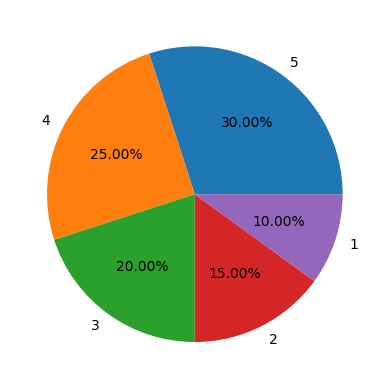

In [19]:
import matplotlib.pyplot as plt
plt.pie(final_df['rating'].value_counts(),labels=final_df['rating'].value_counts().index,autopct='%1.2f%%')
plt.show()

In [20]:
final_df['rating'].value_counts()

,count
rating,
5,7308
4,6090
3,4872
2,3654
1,2436


In [21]:
final_df['review']=final_df['review'].astype(str).str.lower()

In [22]:
final_df.shape

(24360, 2)

REMOVING STOPWORDS

In [24]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(str(text))  # tokenize text
    filtered = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered)
final_df['review']=final_df['review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [28]:
stop_words = set(stopwords.words('english'))

# Display total count and all stopwords
print("Total stopwords:", len(stop_words))
print(sorted(stop_words))  # Sorted alphabetically

Total stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', '

In [26]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = final_df[final_df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. really rude disturbing incident team knowhow engineer came house fix freezer ongoing problem extremely rude asked get old towels threw boiling hot water kettle inside freezer went onto hacked back freezer ice pick left ice water kitchen floor told due door closing seal tried explain always make sure seal shut door closed properly argued last engineer visited house behave like also taken silver foil glue back left floor see ryan left reply ryan wrote email photos mess engineer left ceo came back email either wrong blocked

2. part recommended returned add extra annoyance past using site excellent service im disappointed

3. ordered phone th said weeks delivery time next day said days waited days gone phoned mpd asked changed quickly told depends stock levels stated days asked phone arrive itll days basically keep extending waiting time days knows arrive almost tempted wait new samsung released next year rate extremely annoyed well due get ex

LEMMATIZATION

In [27]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)
final_df['review']=final_df['review'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [30]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = final_df[final_df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. really rude disturbing incident team knowhow engineer came house fix freezer ongoing problem extremely rude asked get old towel threw boiling hot water kettle inside freezer went onto hacked back freezer ice pick left ice water kitchen floor told due door closing seal tried explain always make sure seal shut door closed properly argued last engineer visited house behave like also taken silver foil glue back left floor see ryan left reply ryan wrote email photo mess engineer left ceo came back email either wrong blocked

2. part recommended returned add extra annoyance past using site excellent service im disappointed

3. ordered phone th said week delivery time next day said day waited day gone phoned mpd asked changed quickly told depends stock level stated day asked phone arrive itll day basically keep extending waiting time day know arrive almost tempted wait new samsung released next year rate extremely annoyed well due get extra cash b

In [31]:
short_counts = final_df[final_df['review'].apply(lambda x: len(str(x).split()) < 3)] \
                .groupby('rating').size().reset_index(name='count_less_than_3_words')

print(short_counts)
long_counts = final_df[final_df['review'].apply(lambda x: len(str(x).split()) > 50)] \
               .groupby('rating').size().reset_index(name='count_long_reviews')

print(long_counts)


   rating  count_less_than_3_words
0       1                        5
1       2                        6
2       3                       73
3       4                       86
4       5                      113
   rating  count_long_reviews
0       1                1006
1       2                1931
2       3                1639
3       4                1871
4       5                 887


TRAIN TEST SPLIT

In [34]:
from sklearn.model_selection import train_test_split
x=final_df['review']
y=final_df['rating']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

TF-IDF VECTORIZER

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(x_train)
X_test = vectorizer.transform(x_test)
